## Сравнение гамильтонианов $ \sum S^z_jS^z_{j+1} \sim - 4 \sum n^a_{j}n^a_{j+1} $

In [6]:
import math
import itertools

import joblib
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import qutip
from tqdm import tqdm

In [7]:
import sys
import pathlib

sys.path.append(str(pathlib.Path(sys.path[0]).parent / "libs"))

In [8]:
%reload_ext autoreload
%autoreload 2

import bec
import entanglement_propagation
from tools.jupyter import print_model_info
from tools.qutip import TqdmProgressBar
from tools.plot import set_xlabel_as_pi_fraction

In [9]:
n_jobs = 1

In [10]:
n_bosons = 3
model = bec.BEC_Qubits.init_default(n_bosons, 0)


i_projection = n_bosons

print_model_info(model)

BEC_Qubits(n_bosons=3, coupling_strength=1, transition_ampl=1, transition_freq=11, resonance_freq=1, phase=0, excitation_level=False, communication_line=False)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [11]:
t_span = np.linspace(0, np.pi / 4, 301)

### M=2

In [14]:
%time state_hzz_m2_exact_span = [bec.state_under_h_zz_teor(model, t / model.Omega) for t in tqdm(t_span)]

100%|██████████| 301/301 [00:01<00:00, 216.46it/s]

CPU times: user 1.37 s, sys: 65.3 ms, total: 1.43 s
Wall time: 1.39 s


In [15]:
%time state_hnn_m2_exact_span = [bec.state_under_h_nn_exact(model, 4 * t) for t in tqdm(t_span)]

100%|██████████| 301/301 [00:01<00:00, 229.02it/s]

CPU times: user 1.3 s, sys: 33.9 ms, total: 1.33 s
Wall time: 1.32 s


In [16]:
%time state_hnn_m2_exact_private_span = [entanglement_propagation.f_state(t * 4, [i_projection], 2, n_bosons, focked=False) for t in tqdm(t_span)]

100%|██████████| 301/301 [00:05<00:00, 56.35it/s]

CPU times: user 5.25 s, sys: 246 ms, total: 5.5 s
Wall time: 5.34 s


In [10]:
%time hnn_m2 = - bec.na(model, n=2, k=0) * bec.na(model, n=2, k=1)

CPU times: user 536 µs, sys: 39 µs, total: 575 µs
Wall time: 547 µs


In [11]:
init_state_m2 = (
    bec.coherent_state_constructor(model, n=2, k=0)
    * bec.coherent_state_constructor(model, n=2, k=1)
    * bec.vacuum_state(model, n=2)
)

In [12]:
state_hnn_m2_span = qutip.sesolve(
    hnn_m2,
    init_state_m2,
    t_span * 4,
    progress_bar=TqdmProgressBar(),
    options=qutip.Options(atol=1e-10),
).states

/Users/kephircheek/venvs/science/emqwuqoc-dev/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 301/301 [00:00<00:00, 10841.81it/s]


#### Энтропия

In [13]:
entropy_hnn_m2_span = [
    qutip.entropy.entropy_vn(qutip.ptrace(s, [0, 1]), base=2)
    for s in tqdm(state_hnn_m2_span)
]
entropy_hzz_m2_exact_span = [
    qutip.entropy.entropy_vn(qutip.ptrace(s, [0, 1]), base=2)
    for s in tqdm(state_hzz_m2_exact_span)
]
entropy_hnn_m2_exact_span = [
    qutip.entropy.entropy_vn(qutip.ptrace(s, [0, 1]), base=2)
    for s in tqdm(state_hnn_m2_exact_span)
]

100%|██████████| 301/301 [00:00<00:00, 6933.38it/s]


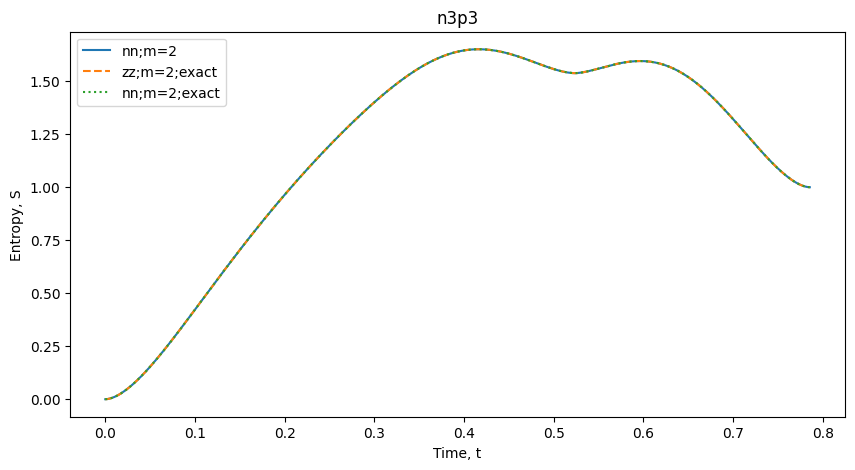

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(t_span, entropy_hnn_m2_span, label=f"nn;m=2")
ax.plot(t_span, entropy_hzz_m2_exact_span, "--", label=f"zz;m=2;exact")
ax.plot(t_span, entropy_hnn_m2_exact_span, ":", label=f"nn;m=2;exact")

ax.set_title(f"n{n_bosons}p{i_projection}")
ax.set_ylabel("Entropy, S")
ax.set_xlabel("Time, t")
ax.legend()

#### Фиделити

In [15]:
fid_hnn_m2_exact_private_respect_to_hnn_m2_exact_span = [
    qutip.metrics.fidelity(a, b)
    for a, b in tqdm(
        zip(state_hnn_m2_exact_private_span, state_hnn_m2_exact_span),
        total=len(state_hnn_m2_exact_span),
    )
]

100%|██████████| 301/301 [00:00<00:00, 50469.14it/s]


In [16]:
fid_hnn_m2_respect_to_hnn_m2_exact_span = [
    qutip.metrics.fidelity(a, b)
    for a, b in tqdm(
        zip(state_hnn_m2_span, state_hnn_m2_exact_span), total=len(state_hnn_m2_span)
    )
]

100%|██████████| 301/301 [00:00<00:00, 147918.63it/s]


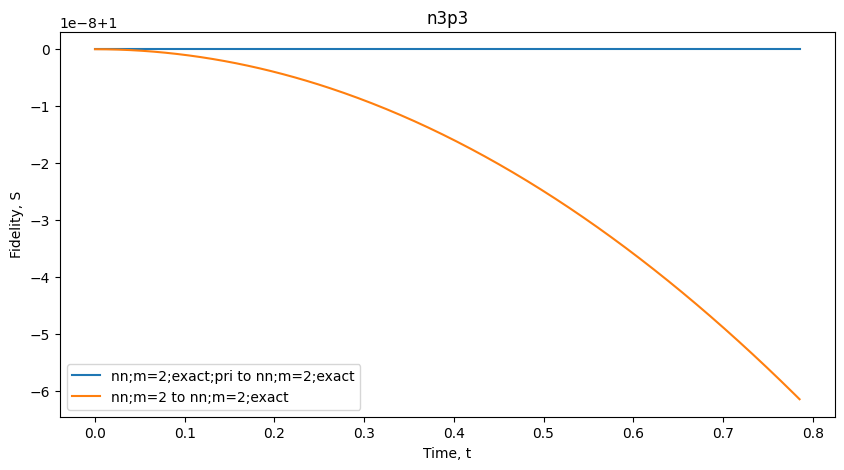

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.plot(
    t_span,
    fid_hnn_m2_exact_private_respect_to_hnn_m2_exact_span,
    label=f"nn;m=2;exact;pri to nn;m=2;exact",
)
ax.plot(
    t_span, fid_hnn_m2_respect_to_hnn_m2_exact_span, label=f"nn;m=2 to nn;m=2;exact"
)

ax.set_title(f"n{n_bosons}p{i_projection}")
ax.set_ylabel("Fidelity, S")
ax.set_xlabel("Time, t")
ax.legend()

### M = 3

In [18]:
init_state_m3 = (
    # np.prod([bec.coherent_state_constructor(model, n=m, k=i) for i in range(m)]) # 100x slowly
    math.prod(bec.coherent_state_constructor(model, n=3, k=i) for i in range(3))
    * bec.vacuum_state(model, n=3)
)

In [19]:
%time h_zz_m3 = sum(bec.sz(model, n=3, k=i) * bec.sz(model, n=3, k=i+1) for i in range(2))

CPU times: user 9.96 ms, sys: 2.03 ms, total: 12 ms
Wall time: 4.13 ms


In [20]:
%time h_nn_m3 = sum((-1)**(i + 1) * bec.na(model, n=3, k=i) * bec.na(model, n=3, k=i+1) for i in range(2))

CPU times: user 5.28 ms, sys: 1.58 ms, total: 6.86 ms
Wall time: 1.91 ms


In [21]:
state_hzz_m3_span = qutip.sesolve(
    h_zz_m3, init_state_m3, t_span, progress_bar=TqdmProgressBar()
).states

100%|██████████| 301/301 [00:00<00:00, 1312.08it/s]


In [22]:
state_hnn_m3_span = qutip.sesolve(
    h_nn_m3, init_state_m3, 4 * t_span, progress_bar=TqdmProgressBar()
).states

100%|██████████| 301/301 [00:00<00:00, 991.55it/s]


Редукция вместо измерения

In [23]:
state_hzz_m3_reduced_span = joblib.Parallel(n_jobs=n_jobs)(
    joblib.delayed(lambda x: qutip.ptrace(x, [0, 1, 4, 5]))(s)
    for s in tqdm(state_hzz_m3_span)
)

100%|██████████| 301/301 [00:00<00:00, 663.76it/s]


Создаем проектор для измерения и проводим измерение

In [24]:
measure_x_m3 = bec.fock_x_state_constructor(model, n=3, i=1, k=i_projection)
measure_x_op_m3 = measure_x_m3 * measure_x_m3.dag()


def measure(state, operator):
    dim = len(state.dims[0])
    state_measured_unnormalized = qutip.ptrace(
        operator * state, [0, 1, dim - 2, dim - 1]
    )
    return state_measured_unnormalized / state_measured_unnormalized.tr()

In [25]:
state_hzz_m3_mesuared_by_x_span = joblib.Parallel(n_jobs=n_jobs)(
    joblib.delayed(measure)(s, measure_x_op_m3) for s in tqdm(state_hzz_m3_span)
)

100%|██████████| 301/301 [00:01<00:00, 278.25it/s]


In [26]:
state_hnn_m3_mesuared_by_x_span = joblib.Parallel(n_jobs=n_jobs)(
    joblib.delayed(measure)(s, measure_x_op_m3) for s in tqdm(state_hnn_m3_span)
)

100%|██████████| 301/301 [00:01<00:00, 295.01it/s]


In [27]:
q = [i_projection]

state_hnn_m3_exact_focked_span = [
    (s := entanglement_propagation.f_state(4 * t, q, m=3, n=n_bosons)) / s.norm()
    for t in tqdm(t_span)
]

state_hnn_m3_exact_span = [
    (s := entanglement_propagation.f_state(4 * t, q, m=3, n=n_bosons, focked=False))
    / s.norm()
    for t in tqdm(t_span)
]

100%|██████████| 301/301 [00:05<00:00, 51.53it/s]


#### Энтропия 

In [28]:
entropy_hzz_m3_span = [
    qutip.entropy.entropy_vn(qutip.ptrace(s, [0, 1]), base=2)
    for s in tqdm(state_hzz_m3_reduced_span)
]
entropy_hzz_m3_x_span = [
    entanglement_propagation.entropy_vn(qutip.ptrace(s, [0, 1]), base=2)
    for s in tqdm(state_hzz_m3_mesuared_by_x_span)
]
entropy_hnn_m3_x_span = [
    entanglement_propagation.entropy_vn(qutip.ptrace(s, [0, 1]), base=2)
    for s in tqdm(state_hnn_m3_mesuared_by_x_span)
]

entropy_state_hnn_m3_exact_span = [
    qutip.entropy.entropy_vn(qutip.ptrace(s, [0, 1]), base=2)
    for s in tqdm(state_hnn_m3_exact_span)
]

entropy_state_hnn_m3_exact_focked_span = [
    qutip.entropy.entropy_vn(qutip.ptrace(s, [0]), base=2)
    for s in tqdm(state_hnn_m3_exact_focked_span)
]

100%|██████████| 301/301 [00:00<00:00, 6916.71it/s]


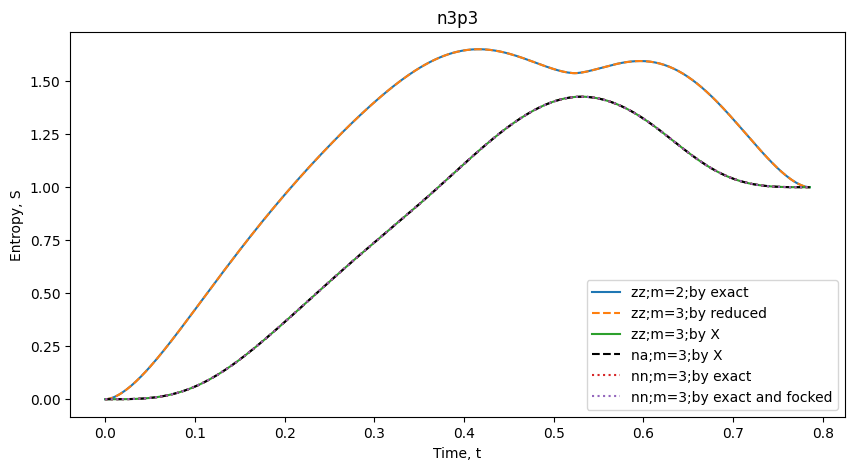

In [29]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(t_span, entropy_hzz_m2_exact_span, label=f"zz;m=2;by exact")
ax.plot(t_span, entropy_hzz_m3_span, "--", label=f"zz;m=3;by reduced")
ax.plot(t_span, entropy_hzz_m3_x_span, "-", label=f"zz;m=3;by X")
ax.plot(t_span, entropy_hnn_m3_x_span, "--k", label=f"na;m=3;by X")
ax.plot(t_span, entropy_state_hnn_m3_exact_span, ":", label=f"nn;m=3;by exact")
ax.plot(
    t_span,
    entropy_state_hnn_m3_exact_focked_span,
    ":",
    label=f"nn;m=3;by exact and focked",
)

ax.set_title(f"n{n_bosons}p{i_projection}")
ax.set_ylabel("Entropy, S")
ax.set_xlabel("Time, t")
ax.legend()

Энтропия действительно совпадает 

#### Фиделити

In [30]:
fid_hzz_m3_reduced_respect_to_hzz_m2_exact_span = [
    qutip.metrics.fidelity(a, b) ** 2
    for a, b in tqdm(
        zip(state_hzz_m2_exact_span, state_hzz_m3_reduced_span),
        total=len(state_hzz_m2_exact_span),
    )
]

100%|██████████| 301/301 [00:00<00:00, 725.58it/s]


In [31]:
fid_hzz_m3_mesuared_by_x_respect_to_hzz_m2_exact_span = [
    qutip.metrics.fidelity(a, b) ** 2
    for a, b in tqdm(
        zip(state_hzz_m2_exact_span, state_hzz_m3_mesuared_by_x_span),
        total=len(state_hzz_m2_exact_span),
    )
]

100%|██████████| 301/301 [00:00<00:00, 790.71it/s]


In [32]:
fid_hnn_m3_mesuared_by_x_respect_to_hzz_m2_exact_span = [
    qutip.metrics.fidelity(a, b) ** 2
    for a, b in tqdm(
        zip(state_hzz_m2_exact_span, state_hnn_m3_mesuared_by_x_span),
        total=len(state_hzz_m2_exact_span),
    )
]

100%|██████████| 301/301 [00:00<00:00, 756.24it/s]


In [33]:
fid_hnn_n3_mesuared_by_x_respect_to_hnn_m2_exact_span = [
    qutip.metrics.fidelity(a, b) ** 2
    for a, b in tqdm(
        zip(state_hnn_m2_exact_span, state_hnn_m3_mesuared_by_x_span),
        total=len(state_hnn_m2_exact_span),
    )
]

100%|██████████| 301/301 [00:00<00:00, 709.06it/s]


In [34]:
fid_hnn_m3_mesuared_by_x_respect_to_hnn_m3_exact_span = [
    qutip.metrics.fidelity(a, b)
    for a, b in tqdm(
        zip(state_hnn_m3_exact_span, state_hnn_m3_mesuared_by_x_span),
        total=len(state_hnn_m3_exact_span),
    )
]

100%|██████████| 301/301 [00:00<00:00, 782.27it/s]


In [42]:
def special_reference_state_for_odd_chains(model):
    return sum(
        (
            math.sqrt(math.comb(model.n_bosons, k1))
            * math.sqrt(math.comb(model.n_bosons, k2))
            * bec.fock_state_constructor(model, 2, 0, k1)
            * bec.fock_state_constructor(model, 2, 1, k2)
            * bec.vacuum_state(model)
        )
        for k1, k2 in itertools.product(range(model.n_bosons + 1), range(model.n_bosons + 1))
    ) / math.sqrt(2**model.n_bosons)**2

In [64]:
def special_reference_state_for_odd_chains2(model):
    return sum(
        (
            math.sqrt(math.comb(model.n_bosons, k))
            * math.sqrt(math.comb(model.n_bosons, k))
            * bec.fock_state_constructor(model, 2, 0, k)
            * bec.fock_state_constructor(model, 2, 1, k)
            * bec.vacuum_state(model)
        )
        for k in range(model.n_bosons + 1)
    ) / math.sqrt(2**model.n_bosons)

In [65]:
special_reference_state_for_odd_chains_ = special_reference_state_for_odd_chains2(model)

In [66]:
special_reference_state_for_odd_chains_ /= special_reference_state_for_odd_chains_.norm()

In [67]:
fid_hnn_m3_mesuared_by_x_respect_to_spec_ref_state_span = [
    qutip.metrics.fidelity(special_reference_state_for_odd_chains_, b)
    for b in tqdm(
        state_hnn_m3_mesuared_by_x_span,
        total=len(state_hnn_m3_mesuared_by_x_span),
        ncols=80,
    )
]


100%|████████████████████████████████████████| 301/301 [00:00<00:00, 799.65it/s]


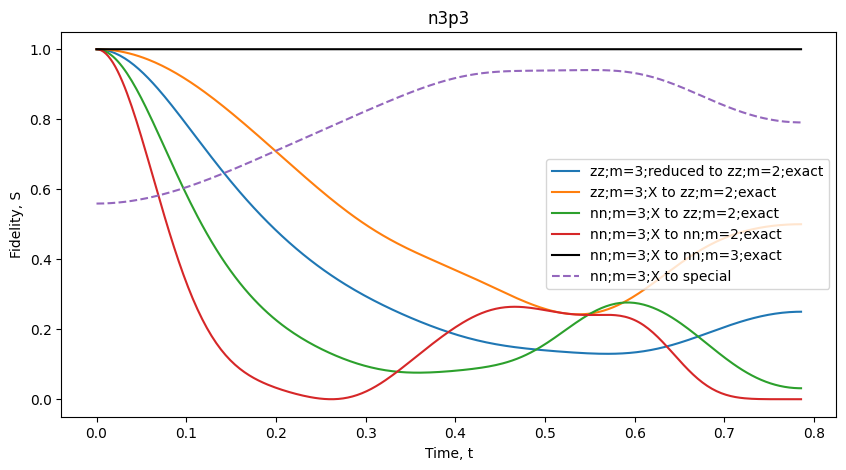

In [68]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(
    t_span,
    fid_hzz_m3_reduced_respect_to_hzz_m2_exact_span,
    "-",
    label=f"zz;m=3;reduced to zz;m=2;exact",
)
ax.plot(
    t_span,
    fid_hzz_m3_mesuared_by_x_respect_to_hzz_m2_exact_span,
    "-",
    label=f"zz;m=3;X to zz;m=2;exact",
)
ax.plot(
    t_span,
    fid_hnn_m3_mesuared_by_x_respect_to_hzz_m2_exact_span,
    "-",
    label=f"nn;m=3;X to zz;m=2;exact",
)
ax.plot(
    t_span,
    fid_hnn_n3_mesuared_by_x_respect_to_hnn_m2_exact_span,
    "-",
    label=f"nn;m=3;X to nn;m=2;exact",
)
ax.plot(
    t_span,
    fid_hnn_m3_mesuared_by_x_respect_to_hnn_m3_exact_span,
    "-k",
    label=f"nn;m=3;X to nn;m=3;exact",
)

ax.plot(
    t_span,
    fid_hnn_m3_mesuared_by_x_respect_to_spec_ref_state_span,
    "--",
    label=f"nn;m=3;X to special",
)


ax.set_title(f"n{n_bosons}p{i_projection}")
ax.set_ylabel("Fidelity, S")
ax.set_xlabel("Time, t")
ax.legend()

Фиделити для Гамильтониана NN

In [36]:
fid_hnn_m3_exact_respect_to_hnn_exact_m2_span = [
    qutip.metrics.fidelity(a / a.norm(), b) ** 2
    for a, b in tqdm(
        zip(state_hnn_m3_exact_span, state_hnn_m2_exact_span),
        total=len(state_hnn_m3_exact_span),
    )
]

100%|██████████| 301/301 [00:00<00:00, 16166.44it/s]


In [37]:
fid_hnn_m3_mesuared_by_x_respect_to_hnn_m2_exact_span = [
    qutip.metrics.fidelity(a, b) ** 2
    for a, b in tqdm(
        zip(state_hnn_m3_mesuared_by_x_span, state_hnn_m2_exact_span),
        total=len(state_hnn_m3_mesuared_by_x_span),
    )
]

100%|██████████| 301/301 [00:00<00:00, 749.50it/s]


In [38]:
fid_hnn_m3_respect_to_hnn_m2_exact_span = [
    entanglement_propagation.f_state_fid_respect_m2(4 * t, q, 3, n_bosons)
    for t in t_span
]

In [39]:
state_hnn_m3_exact_unnormilized_span = [
    entanglement_propagation.f_state(4 * t, q, m=3, n=n_bosons, focked=False)
    for t in tqdm(t_span)
]


fid_hnn_m3_exact_unnormilized_respect_to_f_state_exact_m2_span = [
    qutip.metrics.fidelity(a, b) ** 2
    for a, b in tqdm(
        zip(state_hnn_m3_exact_unnormilized_span, state_hnn_m2_exact_span),
        total=len(state_hnn_m3_exact_unnormilized_span),
    )
]

fid_by_dot_hnn_m3_exact_unnormilized_respect_to_hnn_m2_exact_span = [
    (a.dag() * b).norm() ** 2
    for a, b in tqdm(
        zip(state_hnn_m3_exact_unnormilized_span, state_hnn_m2_exact_span),
        total=len(state_hnn_m3_exact_unnormilized_span),
    )
]

100%|██████████| 301/301 [00:00<00:00, 20761.83it/s]


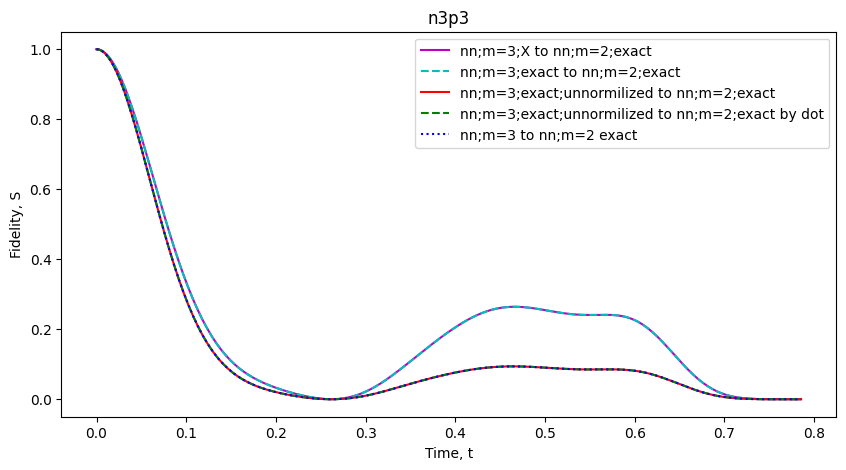

In [40]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(
    t_span,
    fid_hnn_m3_mesuared_by_x_respect_to_hnn_m2_exact_span,
    "-m",
    label=f"nn;m=3;X to nn;m=2;exact",
)
ax.plot(
    t_span,
    fid_hnn_m3_exact_respect_to_hnn_exact_m2_span,
    "--c",
    label=f"nn;m=3;exact to nn;m=2;exact",
)

ax.plot(
    t_span,
    fid_hnn_m3_exact_unnormilized_respect_to_f_state_exact_m2_span,
    "-r",
    label=f"nn;m=3;exact;unnormilized to nn;m=2;exact",
)
ax.plot(
    t_span,
    fid_by_dot_hnn_m3_exact_unnormilized_respect_to_hnn_m2_exact_span,
    "--g",
    label=f"nn;m=3;exact;unnormilized to nn;m=2;exact by dot",
)
ax.plot(
    t_span,
    fid_hnn_m3_respect_to_hnn_m2_exact_span,
    ":b",
    label=f"nn;m=3 to nn;m=2 exact",
)


ax.set_title(f"n{n_bosons}p{i_projection}")
ax.set_ylabel("Fidelity, S")
ax.set_xlabel("Time, t")
ax.legend()

### M=4

In [7]:
q = [i_projection, i_projection]

In [8]:
init_state_m4 = (
    # np.prod([bec.coherent_state_constructor(model, n=m, k=i) for i in range(m)]) # 100x slowly
    math.prod(bec.coherent_state_constructor(model, n=4, k=i) for i in range(4))
    * bec.vacuum_state(model, n=4)
)

In [9]:
%time h_nn_m4 = sum((-1)**(i + 1) * bec.na(model, n=4, k=i) * bec.na(model, n=4, k=i+1) for i in range(3))

CPU times: user 29.5 ms, sys: 4.68 ms, total: 34.2 ms
Wall time: 33.1 ms


In [10]:
print(f"{math.prod(h_nn_m4.shape) * 8 / 1024 ** 3:} Gb")

32.0 Gb


In [11]:
state_hnn_m4_span = qutip.sesolve(
    h_nn_m4, init_state_m4, 4 * t_span, progress_bar=TqdmProgressBar()
).states

/Users/kephircheek/venvs/science/emqwuqoc-dev/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 301/301 [00:05<00:00, 56.19it/s]


Создаем проектор для измерения и проводим измерение

In [12]:
measure_x_m4_i1 = bec.fock_x_state_constructor(model, n=4, i=1, k=i_projection)
measure_x_op_m4_i1 = measure_x_m4_i1 * measure_x_m4_i1.dag()

measure_x_m4_i2 = bec.fock_x_state_constructor(model, n=4, i=2, k=i_projection)
measure_x_op_m4_i2 = measure_x_m4_i2 * measure_x_m4_i2.dag()


def measure(state, operator):
    dim = len(state.dims[0])
    state_measured_unnormalized = qutip.ptrace(
        operator * state, [0, 1, dim - 2, dim - 1]
    )
    return state_measured_unnormalized / state_measured_unnormalized.tr()

In [13]:
state_hnn_m4_mesuared_by_xz_span = joblib.Parallel(n_jobs=n_jobs)(
    joblib.delayed(measure)(s, measure_x_op_m4_i1 * measure_x_op_m4_i2)
    for s in tqdm(state_hnn_m4_span)
)

100%|██████████| 301/301 [00:04<00:00, 74.20it/s]


In [17]:
fid_hnn_m4_mesuared_by_xz_respect_to_hnn_m2_exact_span = [
    qutip.metrics.fidelity(a, b) ** 2
    for a, b in tqdm(
        zip(state_hnn_m4_mesuared_by_xz_span, state_hnn_m2_exact_span),
        total=len(state_hnn_m2_exact_span),
    )
]

100%|██████████| 301/301 [00:00<00:00, 728.60it/s]


In [18]:
state_hnn_m4_exact_unnormilized_span = [
    entanglement_propagation.f_state(4 * t, q, m=4, n=n_bosons, focked=False)
    for t in tqdm(t_span)
]

100%|██████████| 301/301 [00:20<00:00, 14.37it/s]


#### Фиделити

In [19]:
fid_hnn_m4_exact_unnormilized_respect_to_hnn_m2_exact_span = [
    qutip.metrics.fidelity(a, b) ** 2
    for a, b in tqdm(
        zip(state_hnn_m4_exact_unnormilized_span, state_hnn_m2_exact_span),
        total=len(state_hnn_m2_exact_span),
    )
]

100%|██████████| 301/301 [00:00<00:00, 45268.22it/s]


In [20]:
fid_hnn_m4_exact_respect_to_hnn_m2_exact_span = [
    qutip.metrics.fidelity(a / a.norm(), b) ** 2
    for a, b in tqdm(
        zip(state_hnn_m4_exact_unnormilized_span, state_hnn_m2_exact_span),
        total=len(state_hnn_m2_exact_span),
    )
]

100%|██████████| 301/301 [00:00<00:00, 13197.22it/s]


In [21]:
fid_hnn_m4_mesuared_by_xz_respect_to_hnn_m4_exact_span = [
    qutip.metrics.fidelity(a, b / b.norm()) ** 2
    for a, b in tqdm(
        zip(state_hnn_m4_mesuared_by_xz_span, state_hnn_m4_exact_unnormilized_span),
        total=len(state_hnn_m4_exact_unnormilized_span),
    )
]

100%|██████████| 301/301 [00:00<00:00, 703.54it/s]


In [22]:
fid_hnn_m4_unnormilized_respect_to_hnn_m2_exact_span = [
    entanglement_propagation.f_state_fid_respect_m2(
        4 * t, [i_projection, i_projection], 4, n_bosons
    )
    for t in t_span
]

In [59]:
norm_of_fid_hnn_m4_respect_to_hnn_m2_exact_span = np.array([
    entanglement_propagation.f_state_norm(
        4 * t, [i_projection, i_projection], 4, n_bosons
    )
    for t, f in zip(t_span, fid_hnn_m4_unnormilized_respect_to_hnn_m2_exact_span)
])

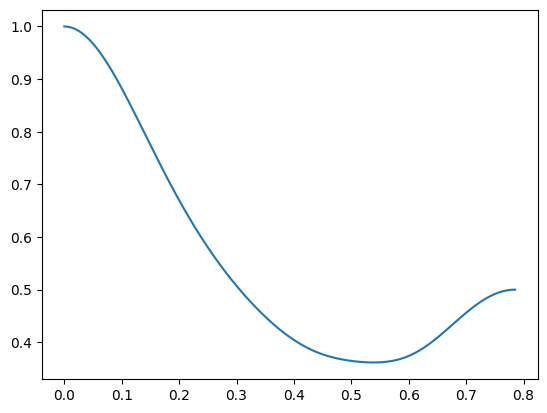

In [60]:
plt.plot(t_span, norm_of_fid_hnn_m4_respect_to_hnn_m2_exact_span)

In [63]:
fid_hnn_m4_respect_to_hnn_m2_exact_span = np.array(fid_hnn_m4_unnormilized_respect_to_hnn_m2_exact_span 
                                                   / norm_of_fid_hnn_m4_respect_to_hnn_m2_exact_span**2)

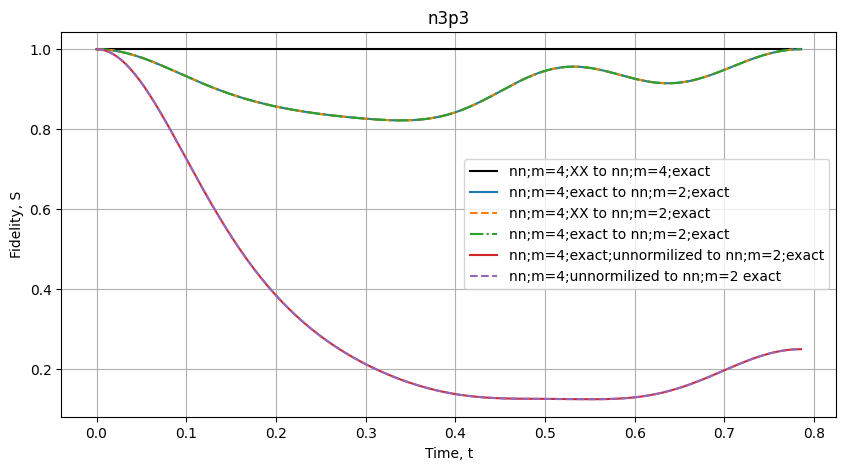

In [64]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(
    t_span,
    fid_hnn_m4_mesuared_by_xz_respect_to_hnn_m4_exact_span,
    "-k",
    label="nn;m=4;XX to nn;m=4;exact",
)
ax.plot(
    t_span,
    fid_hnn_m4_exact_respect_to_hnn_m2_exact_span,
    label="nn;m=4;exact to nn;m=2;exact",
)
ax.plot(
    t_span,
    fid_hnn_m4_mesuared_by_xz_respect_to_hnn_m2_exact_span,
    "--",
    label="nn;m=4;XX to nn;m=2;exact",
)

ax.plot(
    t_span,
    fid_hnn_m4_respect_to_hnn_m2_exact_span,
    "-.",
    label="nn;m=4;exact to nn;m=2;exact",
)

ax.plot(
    t_span,
    fid_hnn_m4_exact_unnormilized_respect_to_hnn_m2_exact_span,
    label="nn;m=4;exact;unnormilized to nn;m=2;exact",
)
ax.plot(
    t_span,
    fid_hnn_m4_unnormilized_respect_to_hnn_m2_exact_span,
    "--",
    label="nn;m=4;unnormilized to nn;m=2 exact",
)
# ax.plot(tspan, fids_f_state_exact_respect_to_f_state_exact_m2_span, "-", label=f"nn;m=3;exact to nn;m=2;exact")
# ax.plot(tspan, fids_f_state_exact_unnormilized_m4_respect_to_f_state_exact_m2_span, "--", label=f"nn;m=4;exact;unnormilized to nn;m=2;exact")
# ax.plot(tspan, fids_f_state_exact_m4_respect_to_f_state_exact_m2_span, "--", label=f"nn;m=4;exact to nn;m=2;exact")
# ax.plot(tspan, fids_f_state_m4_respect_to_f_state_m2_exact_span, "-", label=f"nn;m=4 to nn;m=2 exact")


ax.set_title(f"n{n_bosons}p{i_projection}")
ax.set_ylabel("Fidelity, S")
ax.set_xlabel("Time, t")
ax.legend()
ax.grid()

Вместо косинуса нужно 

$$ \left( \dfrac{e^{i (k_{M-1} - k_1) t} + 1}{2} \right)^N$$

## Сравнение цепочкек разной длины

In [12]:
tspan = np.linspace(0, np.pi, 251)
n_ = 10


def f_state(t, q, m_, n_):
    s = entanglement_propagation.f_state(t, q, m_, n_)
    s /= s.norm() or 1
    return s


f_state_span_by_m = {}

for m_ in range(3, 9):
    q = [n_ for _ in range(m_ - 2)]
    f_state_span = joblib.Parallel(n_jobs=-1)(
        joblib.delayed(f_state)(t, q, m_, n_) for t in tqdm(tspan, postfix=f"m={m_}", ncols=80)
    )
    f_state_span_by_m[m_] = f_state_span

100%|████████████████████████████████████| 251/251 [39:22<00:00,  9.41s/it, m=8]


In [49]:
for m_, f_state_span in f_state_span_by_m.items():
    qutip.qsave(f_state_span, f"../assets/timsway-f_state-m{m_}-n{n_}")

In [50]:
model = bec.BEC_Qubits.init_default(n_, 0)
h_zz_state_n2_exact_span = [
    bec.state_under_h_zz_teor_focked(model, t / model.Omega / 4) for t in tqdm(tspan)
]
h_nn_state_n2_exact_span = [
    bec.state_under_h_na_exact_focked(model, t) for t in tqdm(tspan)
]

100%|██████████| 251/251 [00:01<00:00, 240.22it/s]


### Фиделити между состояниями $H_{nn}$ и $H_{zz}$

100%|██████████| 251/251 [00:00<00:00, 73496.95it/s]


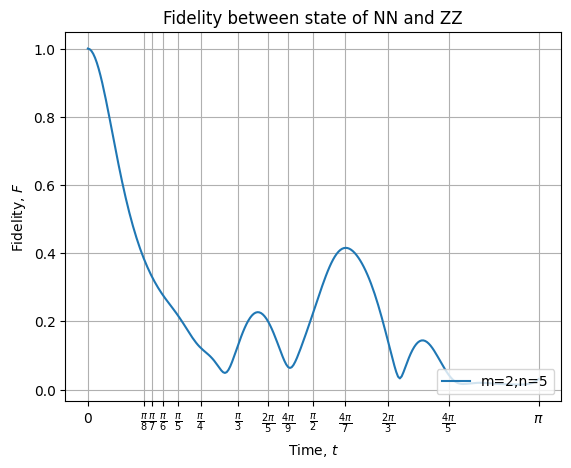

In [51]:
fig, ax = plt.subplots(1, 1)
ax.set_title("Fidelity between state of NN and ZZ")

h_nn_state_fid = [
    qutip.metrics.fidelity(s, s_)
    for s, s_ in tqdm(
        zip(h_zz_state_n2_exact_span, h_nn_state_n2_exact_span),
        total=len(h_nn_state_n2_exact_span),
    )
]
ax.plot(tspan, h_nn_state_fid, label=f"m={2};n={n_}")

set_xlabel_as_pi_fraction(ax)
ax.set_ylabel(r"Fidelity, $F$")
ax.set_xlabel(r"Time, $t$")
ax.legend(loc="lower right")
ax.grid()

### Энтропия

100%|██████████| 251/251 [00:00<00:00, 6786.55it/s]


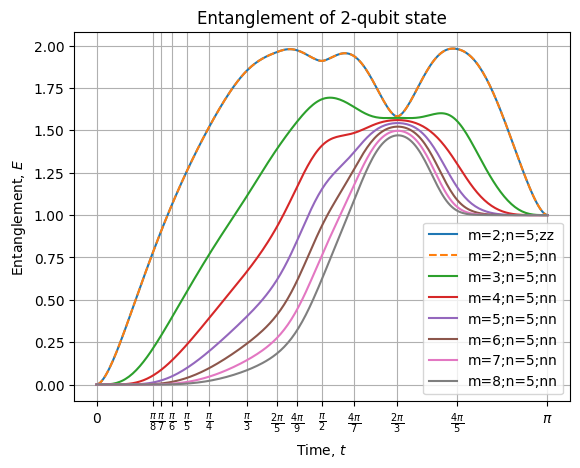

In [52]:
fig, ax = plt.subplots(1, 1)
ax.set_title("Entanglement of 2-qubit state")

hzz_state_entropy = [
    qutip.entropy.entropy_vn(qutip.ptrace(s, [0]), base=2)
    for s in tqdm(h_zz_state_n2_exact_span)
]
ax.plot(tspan, hzz_state_entropy, label=f"m={2};n={n_};zz")

h_nn_state_entropy = [
    qutip.entropy.entropy_vn(qutip.ptrace(s, [0]), base=2)
    for s in tqdm(h_nn_state_n2_exact_span)
]
ax.plot(tspan, h_nn_state_entropy, "--", label=f"m={2};n={n_};nn")

for m_, f_state_span in f_state_span_by_m.items():
    f_state_entropy = [
        qutip.entropy.entropy_vn(qutip.ptrace(s, [0]), base=2)
        for s in tqdm(f_state_span)
    ]
    ax.plot(tspan, f_state_entropy, label=f"m={m_};n={n_};nn")

set_xlabel_as_pi_fraction(ax)
ax.set_xlabel(r"Time, $t$")
ax.set_ylabel(r"Entanglement, $E$")
ax.legend(loc="lower right")
ax.grid()

In [58]:
fig.tight_layout()
fig.savefig(f"../assets/timsway-entanglement-n{n_}.png")

### Фиделити между состояниями

100%|██████████| 251/251 [00:22<00:00, 11.20it/s]


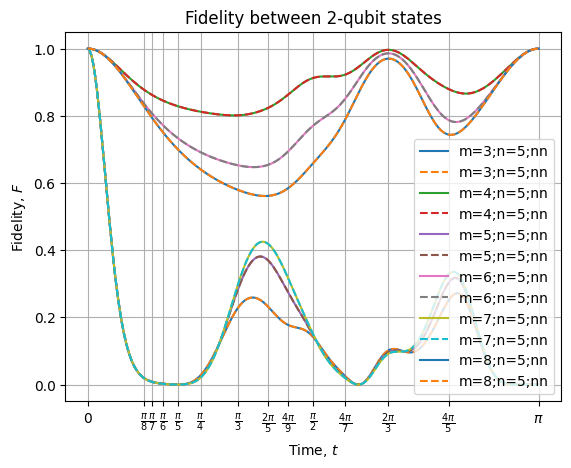

In [65]:
fig, ax = plt.subplots(1, 1)
ax.set_title("Fidelity between 2-qubit states")

for m_, f_state_span in f_state_span_by_m.items():
    f_state_fid = [
        qutip.metrics.fidelity(s, s_)**2
        for s, s_ in tqdm(
            zip(f_state_span, h_nn_state_n2_exact_span),
            total=len(h_nn_state_n2_exact_span),
        )
    ]
 
    f_state_fid_= [
        entanglement_propagation.f_state_fid_respect_m2(t, [n_] * (m_ - 2), m_, n_)
        / entanglement_propagation.f_state_norm(t, [n_] * (m_ - 2), m_, n_) ** 2
        for t in tqdm(tspan)
    ]
    ax.plot(tspan, f_state_fid, label=f"m={m_};n={n_};nn")
    ax.plot(tspan, f_state_fid_, "--", label=f"m={m_};n={n_};nn;exact")

set_xlabel_as_pi_fraction(ax)
ax.set_xlabel(r"Time, $t$")
ax.set_ylabel(r"Fidelity, $F$")
ax.legend(loc="lower right")
ax.grid()

In [60]:
fig.tight_layout()
fig.savefig(f"../assets/timsway-fidelity-n{n_}.png")

100%|██████████| 251/251 [00:00<00:00, 1390.43it/s]


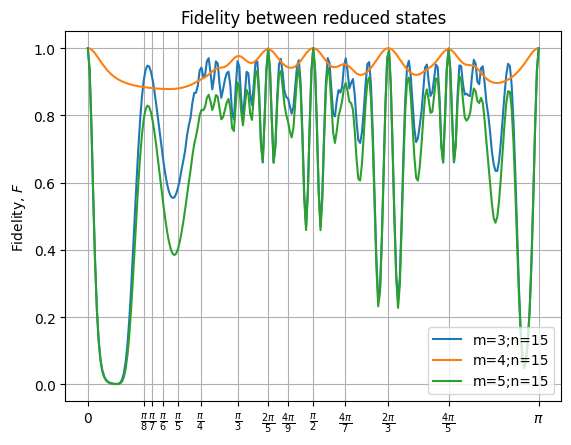

In [61]:
fig, ax = plt.subplots(1, 1)
ax.set_title("Fidelity between reduced states")

for m_, f_state_span in f_state_span_by_m.items():
    f_state_reduced_fid = [
        qutip.metrics.fidelity(qutip.ptrace(s, [1]), qutip.ptrace(s_, [1]))
        for s, s_ in tqdm(
            zip(f_state_span, h_nn_state_n2_exact_span),
            total=len(h_nn_state_n2_exact_span),
        )
    ]
    ax.plot(tspan, f_state_reduced_fid, label=f"m={m_};n={n_}")


set_xlabel_as_pi_fraction(ax)
ax.set_ylabel(r"Fidelity, $F$")
ax.legend(loc="lower right")
ax.grid()

In [62]:
fig.tight_layout()
fig.savefig(f"../assets/timsway-reduced-fidelity-n{n_}.png")